# Populasjonsvekstprognose
I denne oppgåva går eg ut i frå at populasjonsveksten i eit land er avhengig av to faktorar, netto fødselsrate (fødselstal - dødstal) og netto innvandring. Desse treng ikkje vere like kvart år. T.d. er netto fødselsrate i Noreg synkande, medan innvandringa varierer frå år til år. Særleg med meir uro i verda og med aukande verknad av klimaendring, er det ikkje utenkeleg at innvandringa kjem til å auke gradvis i åra framover. Modellen er sjølvsagt likevel ei forenkling i at den relative endringa i fødselsrate og innvandring er stabil.

Skriv inn namnet på landet du vil modelere: 
Norge
Kva er startpopulasjonen til Norge? 
5200000
Kva er netto fødselsrate i Norge
0.02
Er netto fødselsrate i Norge stabil? y = ja, n = nei
n
Kor mykje endrar netto fødselsrate seg per år? (Skriv på desimalform, t.d. -0.03 dersom den avtar med 3% per år)
-0.01
Kva er innvandringsraten i Norge?
0.01
Er netto innvandringsrate i Norge stabil? (y/n)
n
Kor mykje endrar netto innvandringsrate seg per år? (skriv på desimalform, t.d. 0.02 dersom den aukar med 2% per år, og med '-' framfor dersom den avtar)
0.015
Kva er startåret for prognosen? 
2023
Kva er sluttåret for prognosen? 
2050
Folketalet i Norge ved slutten av prognosen, er 11496783


Text(0.5, 1.0, 'Populasjonsvekst i Norge')

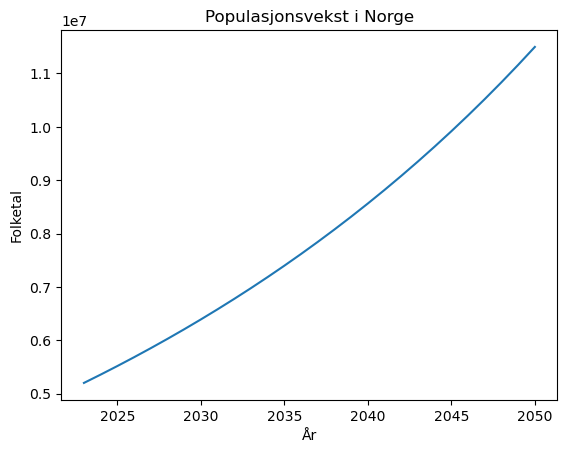

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
e = np.e


land = str(input("Skriv inn namnet på landet du vil modelere: \n"))
P0 = int(input("Kva er startpopulasjonen til {}? \n".format(land)))
fødselsrate = float(input("Kva er netto fødselsrate i {}\n".format(land)))
stabilitet_f = input("Er netto fødselsrate i {} stabil? y = ja, n = nei\n".format(land))

if stabilitet_f == "n":
    fødselsrate_endring = float(input("Kor mykje endrar netto fødselsrate seg per år? (Skriv på desimalform, t.d. -0.03 dersom den avtar med 3% per år)\n"))


innvandringsrate = float(input("Kva er innvandringsraten i {}?\n".format(land)))
stabilitet_i = input("Er netto innvandringsrate i {} stabil? (y/n)\n".format(land))

if stabilitet_i == "n":
    innvandring_endring = float(input("Kor mykje endrar netto innvandringsrate seg per år? (skriv på desimalform, t.d. 0.02 dersom den aukar med 2% per år, og med '-' framfor dersom den avtar)\n"))


startår = int(input("Kva er startåret for prognosen? \n"))
sluttår = int(input("Kva er sluttåret for prognosen? \n"))
t = sluttår - startår

årlig_fødselsrate = [fødselsrate]
for i in range (t):
    fødsel = årlig_fødselsrate[-1] * (1 + fødselsrate_endring)
    årlig_fødselsrate.append(fødsel)
    
årlig_innvandringsrate = [innvandringsrate]
for i in range (t):
    innvandring = årlig_innvandringsrate[-1] * (1 + innvandring_endring)
    årlig_innvandringsrate.append(innvandring)

årlig_vekstrate = []
for i in range (t):
    årlig_vekstrate.append(årlig_fødselsrate[i] + årlig_innvandringsrate[i])

tid = []
for i in range (t+1):
    tid.append(startår + i)

P = [P0]
for i in range (t):
    populasjon = round(P[-1] * (1 + årlig_vekstrate[i]))
    P.append(populasjon)
    
print("Folketalet i {} ved slutten av prognosen, er".format(land), P[t])

plt.plot(tid, P, label="Folketal")
plt.xlabel("År")
plt.ylabel("Folketal")
plt.title("Populasjonsvekst i {}".format(land))

## Samalikning med stabil vekstrate og makspopulasjon
Den førre prognosen tek ikkje hensyn til at det kan vere ein makspopulasjon som ikkje kan overskridast. Under kan vi samalikne korleis populasjonen aukar med modellen for logistisk vekst, eller Verhulstkurva. I denne berekninga hentar modellen startpopulasjon (P0) og tidsperiode for prognosen (t) frå den brukargitte informasjonen i modellen ovanfor.

In [5]:
P_max = int(input("Kva er makspopulasjonen i {} ? \n".format(land)))


A = (P_max - P0) / P0
P_1 = round(P_max / (1 + A * e**(-årlig_vekstrate[0]*t))) #Vekstraten vert antatt å vere den same som startåret i modellen før.


print("Foleketalet i {} ved slutten av denne prognosen er".format(land), P_1, "\n")

if P[t] > P_1:
    print("I dei to prognosene gir den første modellen høgast populasjon,", P[t], ", med ein differanse på", P[t]-P_1, "personar. \n")
elif P[t] == P_1:
    print("Dei to prognosene gir lik populasjon i år {}, lik".format(sluttår), P[t])
else:
    print("I dei to prognosene gir den andre modellen høgast populasjon i år {}, lik".format(t_2), P_1, "med ein differanse på", P_1-P[t], "personar. \n")


Kva er makspopulasjonen i Norge ? 
15000000
Foleketalet i Norge ved slutten av denne prognosen er 8159329 

I dei to prognosene gir den første modellen høgast populasjon, 11496783 , med ein differanse på 3337454 personar. 



Modellen for logistisk vekst gir vesentleg lågare populasjon enn den første modellen. Det er fordi i logistisk modell vil vekstraten avta dess nærare ein kjem makspopulasjonen, fordi det er mindre "plass" eller "ressursar" per individ dess nærare ein kjem maks. Det gjer stort utslag på veksten over tid.